In [1]:
from pathlib import Path
import torch
import sys

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['text.usetex']=True
plt.style.use('classic')

In [2]:
data = torch.load(
    ROOT / "data" / "val.pt",
    weights_only=True
)


x = data["x"]
y_true = data["y"]

print("x:", x.shape)
print("y:", y_true.shape)


train = torch.load(
    ROOT / "data" / "train.pt",
    weights_only=True
)


x: torch.Size([88, 2])
y: torch.Size([88, 192, 192, 3])


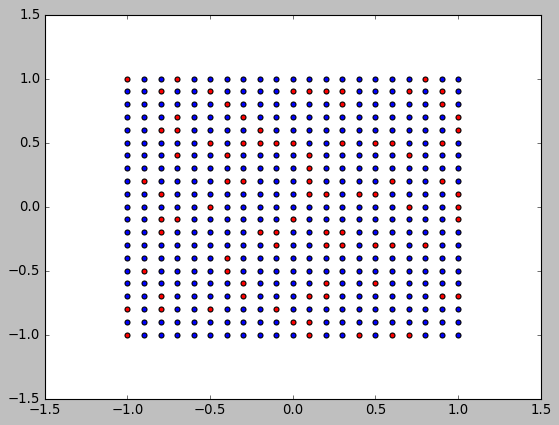

In [3]:
plt.scatter(x[:,0],x[:,1], c='red')
plt.scatter(train["x"][:,0], train["x"][:,1], c='b')

In [4]:
def load_normalization(filename):
    filename = Path(filename)

    norm = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            # Ignore comments and empty lines
            if not line or line.startswith("#"):
                continue

            key, value = line.split("=", 1)

            key = key.strip()
            value = value.strip()

            # eta_encoding is a string
            if key == "eta_encoding":
                norm[key] = value
            else:
                norm[key] = float(value)

    return norm


norm = load_normalization(
    ROOT / "data" / "normalization.txt"
)

print(norm)

{'theta12_min': 30.0, 'theta12_max': 40.0, 'dm21_min': 6e-05, 'dm21_max': 9e-05}


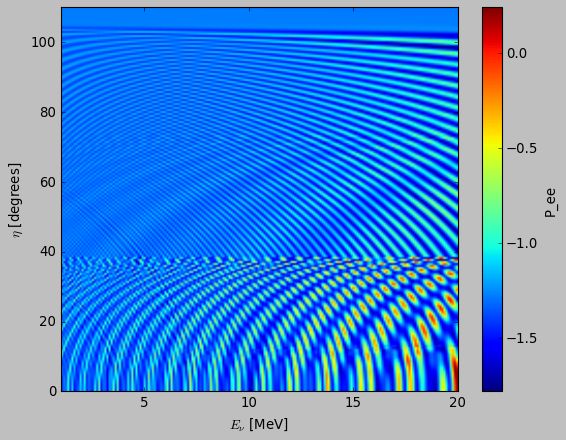

In [7]:
image = y_true[3,:,:,1]



plt.imshow(
    image.numpy(),
    origin='lower',
    extent=[1, 20, 0, 110],
    aspect='auto',
)

plt.xlabel(r'$E_\nu$ [MeV]')
plt.ylabel(r'$\eta$ [degrees]')
plt.colorbar(label='P_ee')
plt.show()